In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Setup complete and ready to go!")


TensorFlow version: 2.20.0
Setup complete and ready to go!


In [2]:
# Load the CIFAR-10 dataset
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to 0-1
x_train, x_test = x_train / 255.0, x_test / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


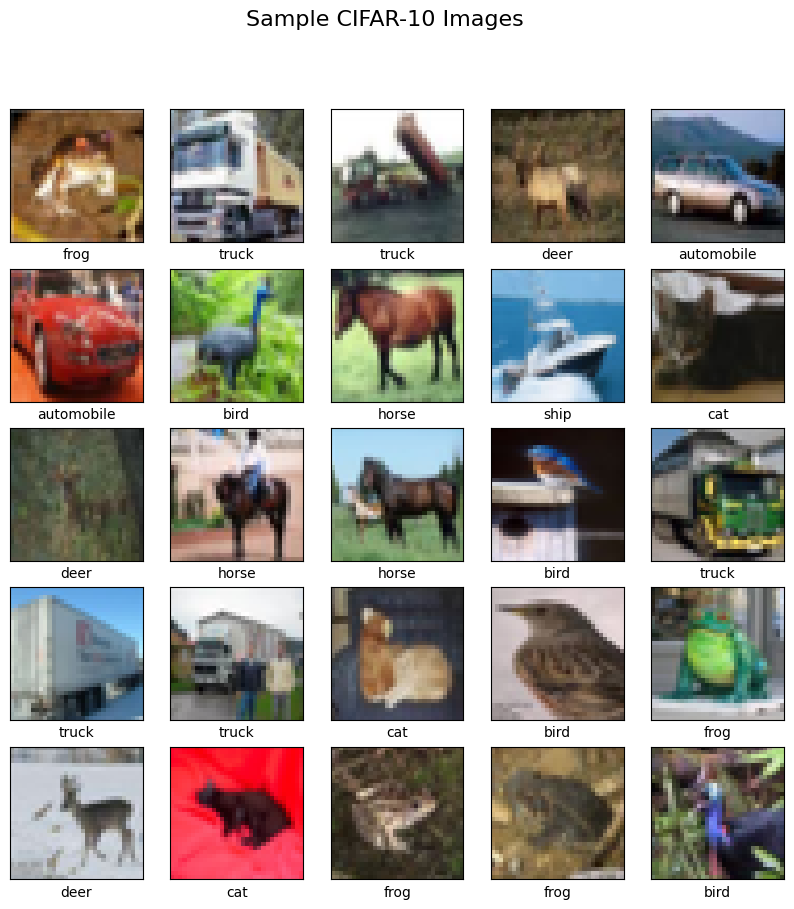

In [3]:
# Class names in CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Show 25 sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])

plt.suptitle("Sample CIFAR-10 Images", fontsize=16)
plt.show()

In [ ]:
from tensorflow.keras import layers, models, Input

model = models.Sequential([
    Input(shape=(32, 32, 3)),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes
])

model.summary()

In [5]:
# Dataset exploration
print("=== CIFAR-10 Dataset Summary ===")
print(f"Training images: {x_train.shape[0]}")
print(f"Test images: {x_test.shape[0]}")
print(f"Image size: {x_train.shape[1]}x{x_train.shape[2]} pixels")
print(f"Colour channels: {x_train.shape[3]} (RGB)")
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

# Check how many images per class
import collections
train_counts = collections.Counter(y_train.flatten())
print("\nImages per class (training):")
for i, name in enumerate(class_names):
    print(f"  {name}: {train_counts[i]}")

=== CIFAR-10 Dataset Summary ===
Training images: 50000
Test images: 10000
Image size: 32x32 pixels
Colour channels: 3 (RGB)
Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Images per class (training):
  airplane: 5000
  automobile: 5000
  bird: 5000
  cat: 5000
  deer: 5000
  dog: 5000
  frog: 5000
  horse: 5000
  ship: 5000
  truck: 5000
